# Fiber masks in single images with SAM 2

Segment Anything Model 2 (SAM 2) predicts object masks given prompts that indicate the desired object. The model first converts the image into an image embedding that allows high quality masks to be efficiently produced from a prompt. 

The `SAM2ImagePredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/segment-anything-2/blob/dev/notebooks/colab_single_image_predictor.ipynb)

## Environment Set-up

If running locally using jupyter, first install `sam2` in your environment using the [installation instructions](https://github.com/facebookresearch/sam2#installation) in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'. Note that it's recommended to use **A100 or L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases).

In [1]:
using_colab = False

In [2]:
%%capture
# --- Packages --
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage.measure import regionprops_table, regionprops
import pandas as pd
from tqdm.auto import tqdm
from time import time

# ===========================================================
#                Google Colab Setup (optional)
# ===========================================================
if using_colab:
    # Install required packages
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/choROPeNt/segment-anything-2.git@dev'

    # Download example images
    !mkdir -p ./images/
    !wget -P ./images/ https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/image_cfrp.tiff
    !wget -P ./images/ https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/image_gfrp.tiff
    !wget -P ./images/ https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/panorama.tif

    # Download SAM2 model checkpoint
    !mkdir -p ./checkpoints/
    !wget -P ./checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
else:
    import sam2

## Set-up

Necessary imports and helper functions for displaying points, boxes, and masks.

In [3]:
# -----------------------------------------------------------
# Select device (CUDA → MPS → CPU)
# -----------------------------------------------------------

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # fallback for unsupported ops
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using PyTorch Version {torch.__version__}")
print(f"Using device: {device}")

# -----------------------------------------------------------
# CUDA-specific optimizations
# -----------------------------------------------------------
if device.type == "cuda":
    # Enable bfloat16 autocast for entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

    # Enable TensorFloat-32 (TF32) on Ampere or newer GPUs
    props = torch.cuda.get_device_properties(0)
    if props.major >= 8:  # Ampere or newer
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

# -----------------------------------------------------------
# MPS warning (Apple Silicon)
# -----------------------------------------------------------
elif device.type == "mps":
    print(
        "\n⚠️  Warning: MPS support in PyTorch is still experimental.\n"
        "    SAM2 is trained on CUDA and may produce slightly different\n"
        "    numerical results or slower performance on MPS.\n"
        "    More details: https://github.com/pytorch/pytorch/issues/84936\n"
    )

Using PyTorch Version 2.8.0
Using device: mps

⚠️  Warning: MPS support in PyTorch is still experimental.
    SAM2 is trained on CUDA and may produce slightly different
    numerical results or slower performance on MPS.
    More details: https://github.com/pytorch/pytorch/issues/84936



In [4]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

## Example image

In [5]:
image = Image.open('../data/promotion/245_004-4_slice-2500-400.tiff')
image_np = np.array(image.convert("RGB"))

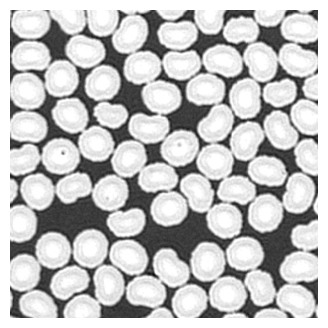

In [6]:
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

## Selecting objects with SAM 2

First, load the SAM 2 model and predictor. Change the path below to point to the SAM 2 checkpoint. Running on CUDA and using the default model are recommended for best results.

In [7]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.addons import show_anns

# set here your checkpoint path and path to yourmodel cfg
sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,                 # The preloaded SAM2 model used for automatic segmentation

    points_per_side=78,         # Sampling density of prompt points per image side.
                                # A higher value → more points → denser coverage, better for small or fine structures,
                                # but also slower and more memory-intensive.

    points_per_batch=64,        # Number of sampled points processed simultaneously by the model.
                                # Controls batch size; balance between speed and GPU memory usage.

    pred_iou_thresh=0.05,        # Minimum predicted IoU between the mask and its region proposal
                                # required to keep a candidate. Lower this to retain weaker (small or uncertain) masks.

    min_mask_region_area=100,    # Minimum area (in pixels) for a mask to be kept.
                                # Increasing this removes tiny specks; decreasing it helps keep very small objects.

    box_nms_thresh=0.2,         # Non-Maximum Suppression (NMS) threshold for filtering overlapping boxes.
                                # Lower values make the filter stricter, keeping fewer overlapping regions.

    stability_score_thresh=0.9  # Confidence threshold measuring mask consistency under perturbations.
                                # Lowering this (e.g. 0.7–0.8) retains more masks, especially smaller or noisier ones.
)

Process the image to produce an image embedding by calling `SAM2ImagePredictor.set_image`. `SAM2ImagePredictor` remembers this embedding and will use it for subsequent mask prediction.

In [8]:
# Detect for one image
print(f"Detection started...")
t0 = time()
masks = mask_generator.generate(image_np)
t = time() - t0
print(f"Detection finished in {t:.3f} seconds...")
print(f"Detected objects: {len(masks)}")

Detection started...


/Users/christian/Projects/segment-anything-2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/Users/christian/Projects/segment-anything-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


Detection finished in 53.360 seconds...
Detected objects: 20


### 🛠️ Post-processing: Removing Spurious Background Masks

In some cases, SAM2 may also generate a mask that corresponds to the image background.
This typically appears as a very large mask that covers most of the image but is not a meaningful object (e.g., not a fiber cross-section).

To filter these out, we sort all detections by their area and remove the largest one if it exceeds a chosen threshold.

In [37]:
# Sort masks by area (largest first)
sorted_masks = sorted(masks, key=lambda m: m["area"], reverse=True)

# Remove the largest mask if it is likely background (area > 1e5 px)
if sorted_masks and sorted_masks[0]["area"] > 1e5:
    sorted_masks = sorted_masks[1:]

In [39]:
print([m["area"] for m in sorted_masks])

[2789, 2779, 2710, 2667, 2639, 2582, 2216, 1931, 1750, 1709, 1657, 1091, 798, 587, 416, 81, 63, 58, 40, 38]


### 🖼️ Vizualization

In this step, we display the detected instances on top of the original image.  
Each mask is assigned a **random color** sampled from the selected Matplotlib colormap (`plasma` in this example).  
You can freely change the colormap to any Matplotlib-supported option (e.g., `viridis`, `magma`, `inferno`, `tab20`, …).  

The transparency of the overlaid masks is controlled by the `alpha` parameter.  
Increasing `alpha` makes the masks more opaque; decreasing it makes the underlying image more visible.

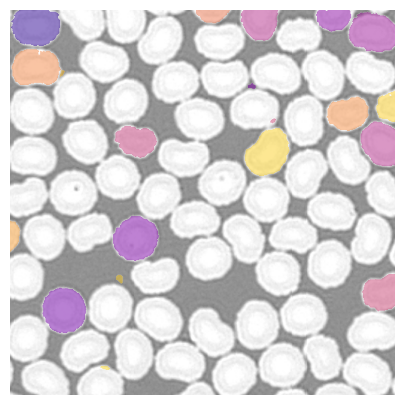

In [40]:
# Display segmented masks on top of the image
plt.figure(figsize=(5, 5))
plt.imshow(image_np)

# Random-color instance masks using the "plasma" colormap
label_canvas = show_anns(
    sorted_masks,
    alpha=0.5,          # overlay transparency (0=transparent, 1=opaque)
    cmap_key="plasma"   # Matplotlib colormap for mask colors
)

plt.axis('off')
plt.show()

Predict with `SAM2ImagePredictor.predict`. The model returns masks, quality predictions for those masks, and low resolution mask logits that can be passed to the next iteration of prediction.

In [15]:


for _ in range(3):  # Run 3 iterations of refinement
    masks, scores, logits = predictor.predict(
        point_coords=input_point[:2],
        point_labels=input_label[:2],
        multimask_output=False
    )
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]

With `multimask_output=True` (the default setting), SAM 2 outputs 3 masks, where `scores` gives the model's own estimation of the quality of these masks. This setting is intended for ambiguous input prompts, and helps the model disambiguate different objects consistent with the prompt. When `False`, it will return a single mask. For ambiguous prompts such as a single point, it is recommended to use `multimask_output=True` even if only a single mask is desired; the best single mask can be chosen by picking the one with the highest score returned in `scores`. This will often result in a better mask.

In [ ]:
masks.shape  # (number_of_masks) x H x W

In [ ]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

## Specifying a specific object with additional points

The single input point is ambiguous, and the model has returned multiple objects consistent with it. To obtain a single object, multiple points can be provided. If available, a mask from a previous iteration can also be supplied to the model to aid in prediction. When specifying a single object with multiple prompts, a single mask can be requested by setting `multimask_output=False`.

In [ ]:
input_point = np.array([[50, 280], [60, 280]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [ ]:
masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

In [ ]:
masks.shape

In [ ]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label)

To exclude the car and specify just the window, a background point (with label 0, here shown in red) can be supplied.

In [ ]:
fiber_embedding = predictor.get_image_embedding()

print(fiber_embedding.shape)
selected_features = image_embedding[:, input_point[:, 1], input_point[:, 0]]

In [ ]:
input_point = np.array([[500, 375], [1125, 625]])
input_label = np.array([1, 0])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [ ]:
masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

In [ ]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label)

## Specifying a specific object with a box

The model can also take a box as input, provided in xyxy format.

In [ ]:
input_box = np.array([425, 600, 700, 875])

In [ ]:
masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)

In [ ]:
show_masks(image, masks, scores, box_coords=input_box)

## Combining points and boxes

Points and boxes may be combined, just by including both types of prompts to the predictor. Here this can be used to select just the trucks's tire, instead of the entire wheel.

In [ ]:
input_box = np.array([425, 600, 700, 875])
input_point = np.array([[575, 750]])
input_label = np.array([0])

In [ ]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)

In [ ]:
show_masks(image, masks, scores, box_coords=input_box, point_coords=input_point, input_labels=input_label)

## Batched prompt inputs

`SAM2ImagePredictor` can take multiple input prompts for the same image, using `predict` method. For example, imagine we have several box outputs from an object detector.

In [ ]:
input_boxes = np.array([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
])

In [ ]:
masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input,
    multimask_output=False,
)

In [ ]:
masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.squeeze(0), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box, plt.gca())
plt.axis('off')
plt.show()

## End-to-end batched inference
If all prompts are available in advance, it is possible to run SAM 2 directly in an end-to-end fashion. This also allows batching over images.

In [ ]:
image1 = image  # truck.jpg from above
image1_boxes = np.array([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
])

image2 = Image.open('images/groceries.jpg')
image2 = np.array(image2.convert("RGB"))
image2_boxes = np.array([
    [450, 170, 520, 350],
    [350, 190, 450, 350],
    [500, 170, 580, 350],
    [580, 170, 640, 350],
])

img_batch = [image1, image2]
boxes_batch = [image1_boxes, image2_boxes]

In [ ]:
predictor.set_image_batch(img_batch)

In [ ]:
masks_batch, scores_batch, _ = predictor.predict_batch(
    None,
    None, 
    box_batch=boxes_batch, 
    multimask_output=False
)

In [ ]:
for image, boxes, masks in zip(img_batch, boxes_batch, masks_batch):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)   
    for mask in masks:
        show_mask(mask.squeeze(0), plt.gca(), random_color=True)
    for box in boxes:
        show_box(box, plt.gca())

Similarly, we can have a batch of point prompts defined over a batch of images

In [ ]:
image1 = image  # truck.jpg from above
image1_pts = np.array([
    [[500, 375]],
    [[650, 750]]
    ]) # Bx1x2 where B corresponds to number of objects 
image1_labels = np.array([[1], [1]])

image2_pts = np.array([
    [[400, 300]],
    [[630, 300]],
])
image2_labels = np.array([[1], [1]])

pts_batch = [image1_pts, image2_pts]
labels_batch = [image1_labels, image2_labels]

In [ ]:
masks_batch, scores_batch, _ = predictor.predict_batch(pts_batch, labels_batch, box_batch=None, multimask_output=True)

# Select the best single mask per object
best_masks = []
for masks, scores in zip(masks_batch,scores_batch):
    best_masks.append(masks[range(len(masks)), np.argmax(scores, axis=-1)])

In [ ]:
for image, points, labels, masks in zip(img_batch, pts_batch, labels_batch, best_masks):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)   
    for mask in masks:
        show_mask(mask, plt.gca(), random_color=True)
    show_points(points, labels, plt.gca())